## Correlation

## Introduction

Correlation is a type of statistical relationship between two random variables or bivariate data. It usually refers to the extent to which a pair of quantities are **linearly related**.

The presence of a correlation is not sufficient to infer the presence of a causal relationship (i.e., correlation does not imply causation). Furthermore, the concept of correlation is not the same as dependence: if two variables are independent, then they are uncorrelated, but the opposite is not necessarily true – even if two variables are uncorrelated, they might be dependent on each other.

## Pearson Correlation Coefficient

The Pearson correlation coefficient (PCC) is a correlation coefficient that measures linear correlation between two sets of data. It is the ratio between the covariance of two variables and the product of their standard deviations; thus, it is essentially a normalized measurement of the covariance, such that the result always has a value between −1 and 1.

$$
\rho_{X,Y} = \frac{\operatorname{cov}(X,Y)}{\sigma_X \sigma_Y}
$$

Where:

- $\operatorname{cov}(X,Y)$ is the covariance between $X$ and $Y$
- $\sigma_X$ is the standard deviation of $X$
- $\sigma_Y$ is the standard deviation of $Y$

The Pearson correlation coefficient describes both the direction and the strength of a linear relationship between two variables.

The **direction** indicates how the variables move relative to each other: a **positive** correlation means that as one variable increases, the other also increases, while a **negative** correlation means that as one variable increases, the other decreases.

The **magnitude** describes how strong this relationship is and is determined by how close the value is to 1 in absolute terms. Values close to +1 or −1 indicate a **strong** relationship, while values close to 0 indicate a **weak** or no linear relationship.

For example, a correlation of `−0.9` indicates a strong negative relationship, whereas a correlation of `0.2` indicates a weak positive relationship.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Data

**Dataset:** https://www.kaggle.com/datasets/sumeakash/impact-of-social-media-on-health

This dataset analyzes the impact of AI and digital platform usage on students' academic and personal life. It contains information about students' demographics, usage behavior, and its effects on performance, mental health, and relationships.

In [2]:
student_df = pd.read_csv("../data/Social_media_impact_on_life.csv")

student_df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


## Checking for Duplicates and Missing Values

In [3]:
student_df.duplicated().any()

np.False_

In [4]:
student_df.isna().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [5]:
student_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   str    
 3   Academic_Level                1705 non-null   str    
 4   Country                       1705 non-null   str    
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   str    
 7   Affects_Academic_Performance  1705 non-null   str    
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 146.7 KB


## Correlation Matrix

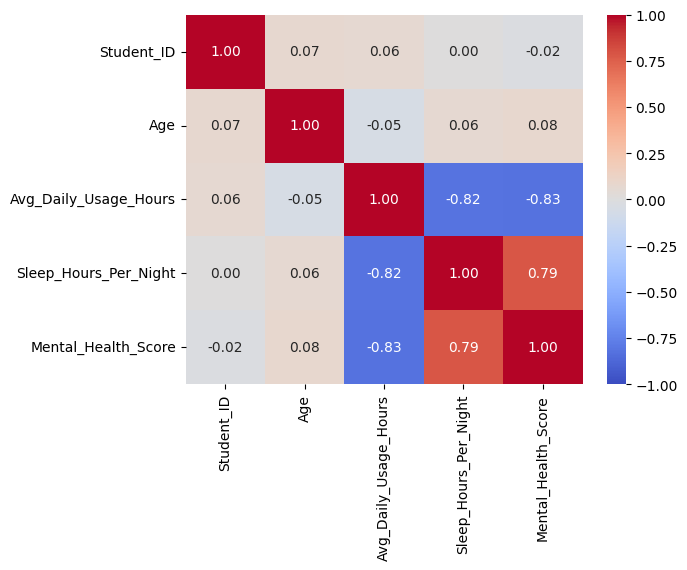

In [6]:
correlations = student_df.corr(numeric_only=True)

sns.heatmap(correlations, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm")
plt.show()

The heatmap visualizes the linear relationships between the numerical variables in the dataset, namely `Age`, `Avg_Daily_Usage_Hours`, `Sleep_Hours_Per_Night`, and `Mental_Health_Score`. Strong relationships are easily identified through more intense color gradients, while weaker relationships appear lighter.

There is a strong negative correlation between `Avg_Daily_Usage_Hours` and `Sleep_Hours_Per_Night` (−0.82), indicating that increased social media usage is associated with reduced sleep. Similarly, `Avg_Daily_Usage_Hours` shows a strong negative correlation with `Mental_Health_Score` (−0.83), suggesting that higher usage is linked to poorer mental health.

In contrast, `Sleep_Hours_Per_Night` and `Mental_Health_Score` exhibit a strong positive correlation (0.79), meaning that better sleep is associated with improved mental health.

Another variable, `Age`, show very weak correlations with the rest, indicating minimal linear relationships and suggesting they have little influence on the key patterns observed. 

The very weak (near-zero) correlations involving `Student_ID` are expected because it is simply an identifier, not a meaningful numerical variable.

## Notes

- Correlation does not imply causation
- Correlation only captures linear relationships
- Outliers can distort results
- Spurious correlations can occur
- Identifier or categorical codes should not be treated as numerical data
- Correlation does not explain underlying mechanisms